<a href="https://colab.research.google.com/github/cocyten27/MODULE_6/blob/main/M6_L18_evaluation_HHDJ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TAE-IA · Module 6 · L18 — Evaluating and Diagnosing the Classifier

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L18 |
| **Track** | B — Audio |
| **Runtime** | T4 GPU (needed for AST inference in Section 2.5) |
| **Drive input** | `ESC50_best.pth`, `ESC50_specs/`, `ESC-50/` |

## Learning objectives

By the end of this notebook you will be able to:
1. Compute and interpret per-class precision, recall, and F1 for a 50-class classifier
2. Generate and read a 50×50 confusion matrix heatmap
3. Identify the top confused category pairs and form acoustic hypotheses for each
4. Run AST (Audio Spectrogram Transformer) inference and compare against the EfficientNet baseline
5. Translate confusion matrix findings into concrete pipeline improvement proposals

---

## Cell 0 — Setup

In [ ]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, random
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

# Models cache on the runtime disk: Drive's mount does not support the symlinks
# huggingface_hub uses, and re-downloading AST costs less than debugging OSError 95.
MODEL_CACHE = '/content/models'
os.makedirs(MODEL_CACHE, exist_ok=True)
ESC50_DIR   = '/content/drive/MyDrive/TAE_IA_M6/ESC-50'
SPEC_DIR    = '/content/drive/MyDrive/TAE_IA_M6/ESC50_specs'
CKPT_PATH   = '/content/drive/MyDrive/TAE_IA_M6/ESC50_best.pth'

os.environ['HF_HOME']            = MODEL_CACHE
os.environ['TORCH_HOME']         = MODEL_CACHE
os.environ['TRANSFORMERS_CACHE'] = os.path.join(MODEL_CACHE, 'hub')

SEED = 42
random.seed(SEED); np.random.seed(SEED)

import torch
torch.manual_seed(SEED)

if not torch.cuda.is_available():
    print('\nNo GPU — go to: Runtime > Change runtime type > T4 GPU')
    raise SystemExit('T4 GPU required for AST inference.')

DEVICE = torch.device('cuda')
print(f'GPU: {torch.cuda.get_device_name(0)}')

# Verify prerequisites
assert os.path.exists(CKPT_PATH),  f'ESC50_best.pth not found at {CKPT_PATH} — run L17 first.'
assert os.path.exists(SPEC_DIR),   f'ESC50_specs not found — run L16 first.'
assert os.path.exists(ESC50_DIR),  f'ESC-50 dataset not found — run L16 first.'
print('All prerequisites found ✓')

Mounted at /content/drive
GPU: Tesla T4
All prerequisites found ✓


In [ ]:
!pip install scikit-learn seaborn torchvision transformers librosa pillow -q

import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import IPython.display as ipd
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
from tqdm.auto import tqdm

print('Imports OK')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

Imports OK


---
## Section 2.1 — Rebuild Model and Collect Test Predictions

We reconstruct the exact same architecture as L17 and load the saved checkpoint.

In [ ]:
meta = pd.read_csv(os.path.join(ESC50_DIR, 'meta', 'esc50.csv'))
test_meta = meta[meta['fold'] == 5].reset_index(drop=True)

# Same transform as L17 — must match exactly
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

test_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1)),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class ESC50Dataset(Dataset):
    def __init__(self, meta_df, spec_dir, transform):
        self.meta = meta_df; self.spec_dir = spec_dir; self.transform = transform
    def __len__(self): return len(self.meta)
    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        img = Image.open(os.path.join(self.spec_dir,
                         row['filename'].replace('.wav', '.png'))).convert('L')
        return self.transform(img), int(row['target'])

test_ds     = ESC50Dataset(test_meta, SPEC_DIR, test_transform)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)
print(f'Test set: {len(test_ds)} clips  |  {len(test_loader)} batches')

Test set: 400 clips  |  13 batches


In [ ]:
# Rebuild EfficientNet-B0 with the same 50-class head as L17
effnet = models.efficientnet_b0(weights=None)
effnet.classifier[1] = nn.Linear(effnet.classifier[1].in_features, 50)
effnet.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
effnet = effnet.to(DEVICE).eval()
print(f'Loaded checkpoint: {CKPT_PATH}')

# Collect all predictions
all_preds, all_targets = [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Collecting predictions'):
        preds = effnet(imgs.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(labels.numpy())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)
effnet_acc  = (all_preds == all_targets).mean()

category_map  = meta.drop_duplicates('target').set_index('target')['category'].sort_index().to_dict()
category_names = [category_map[i] for i in range(50)]

print(f'\nEfficientNet-B0 test accuracy: {effnet_acc:.4f}  ({effnet_acc*100:.1f}%)')

Loaded checkpoint: /content/drive/MyDrive/TAE_IA_M6/ESC50_best.pth



EfficientNet-B0 test accuracy: 0.7550  (75.5%)


---
## Section 2.2 — Confusion Matrix

A 50×50 heatmap. Each cell $(i, j)$ counts how many clips from true class $i$ were predicted as class $j$. The diagonal is correct predictions — we want it to be bright. Off-diagonal bright cells are systematic errors.

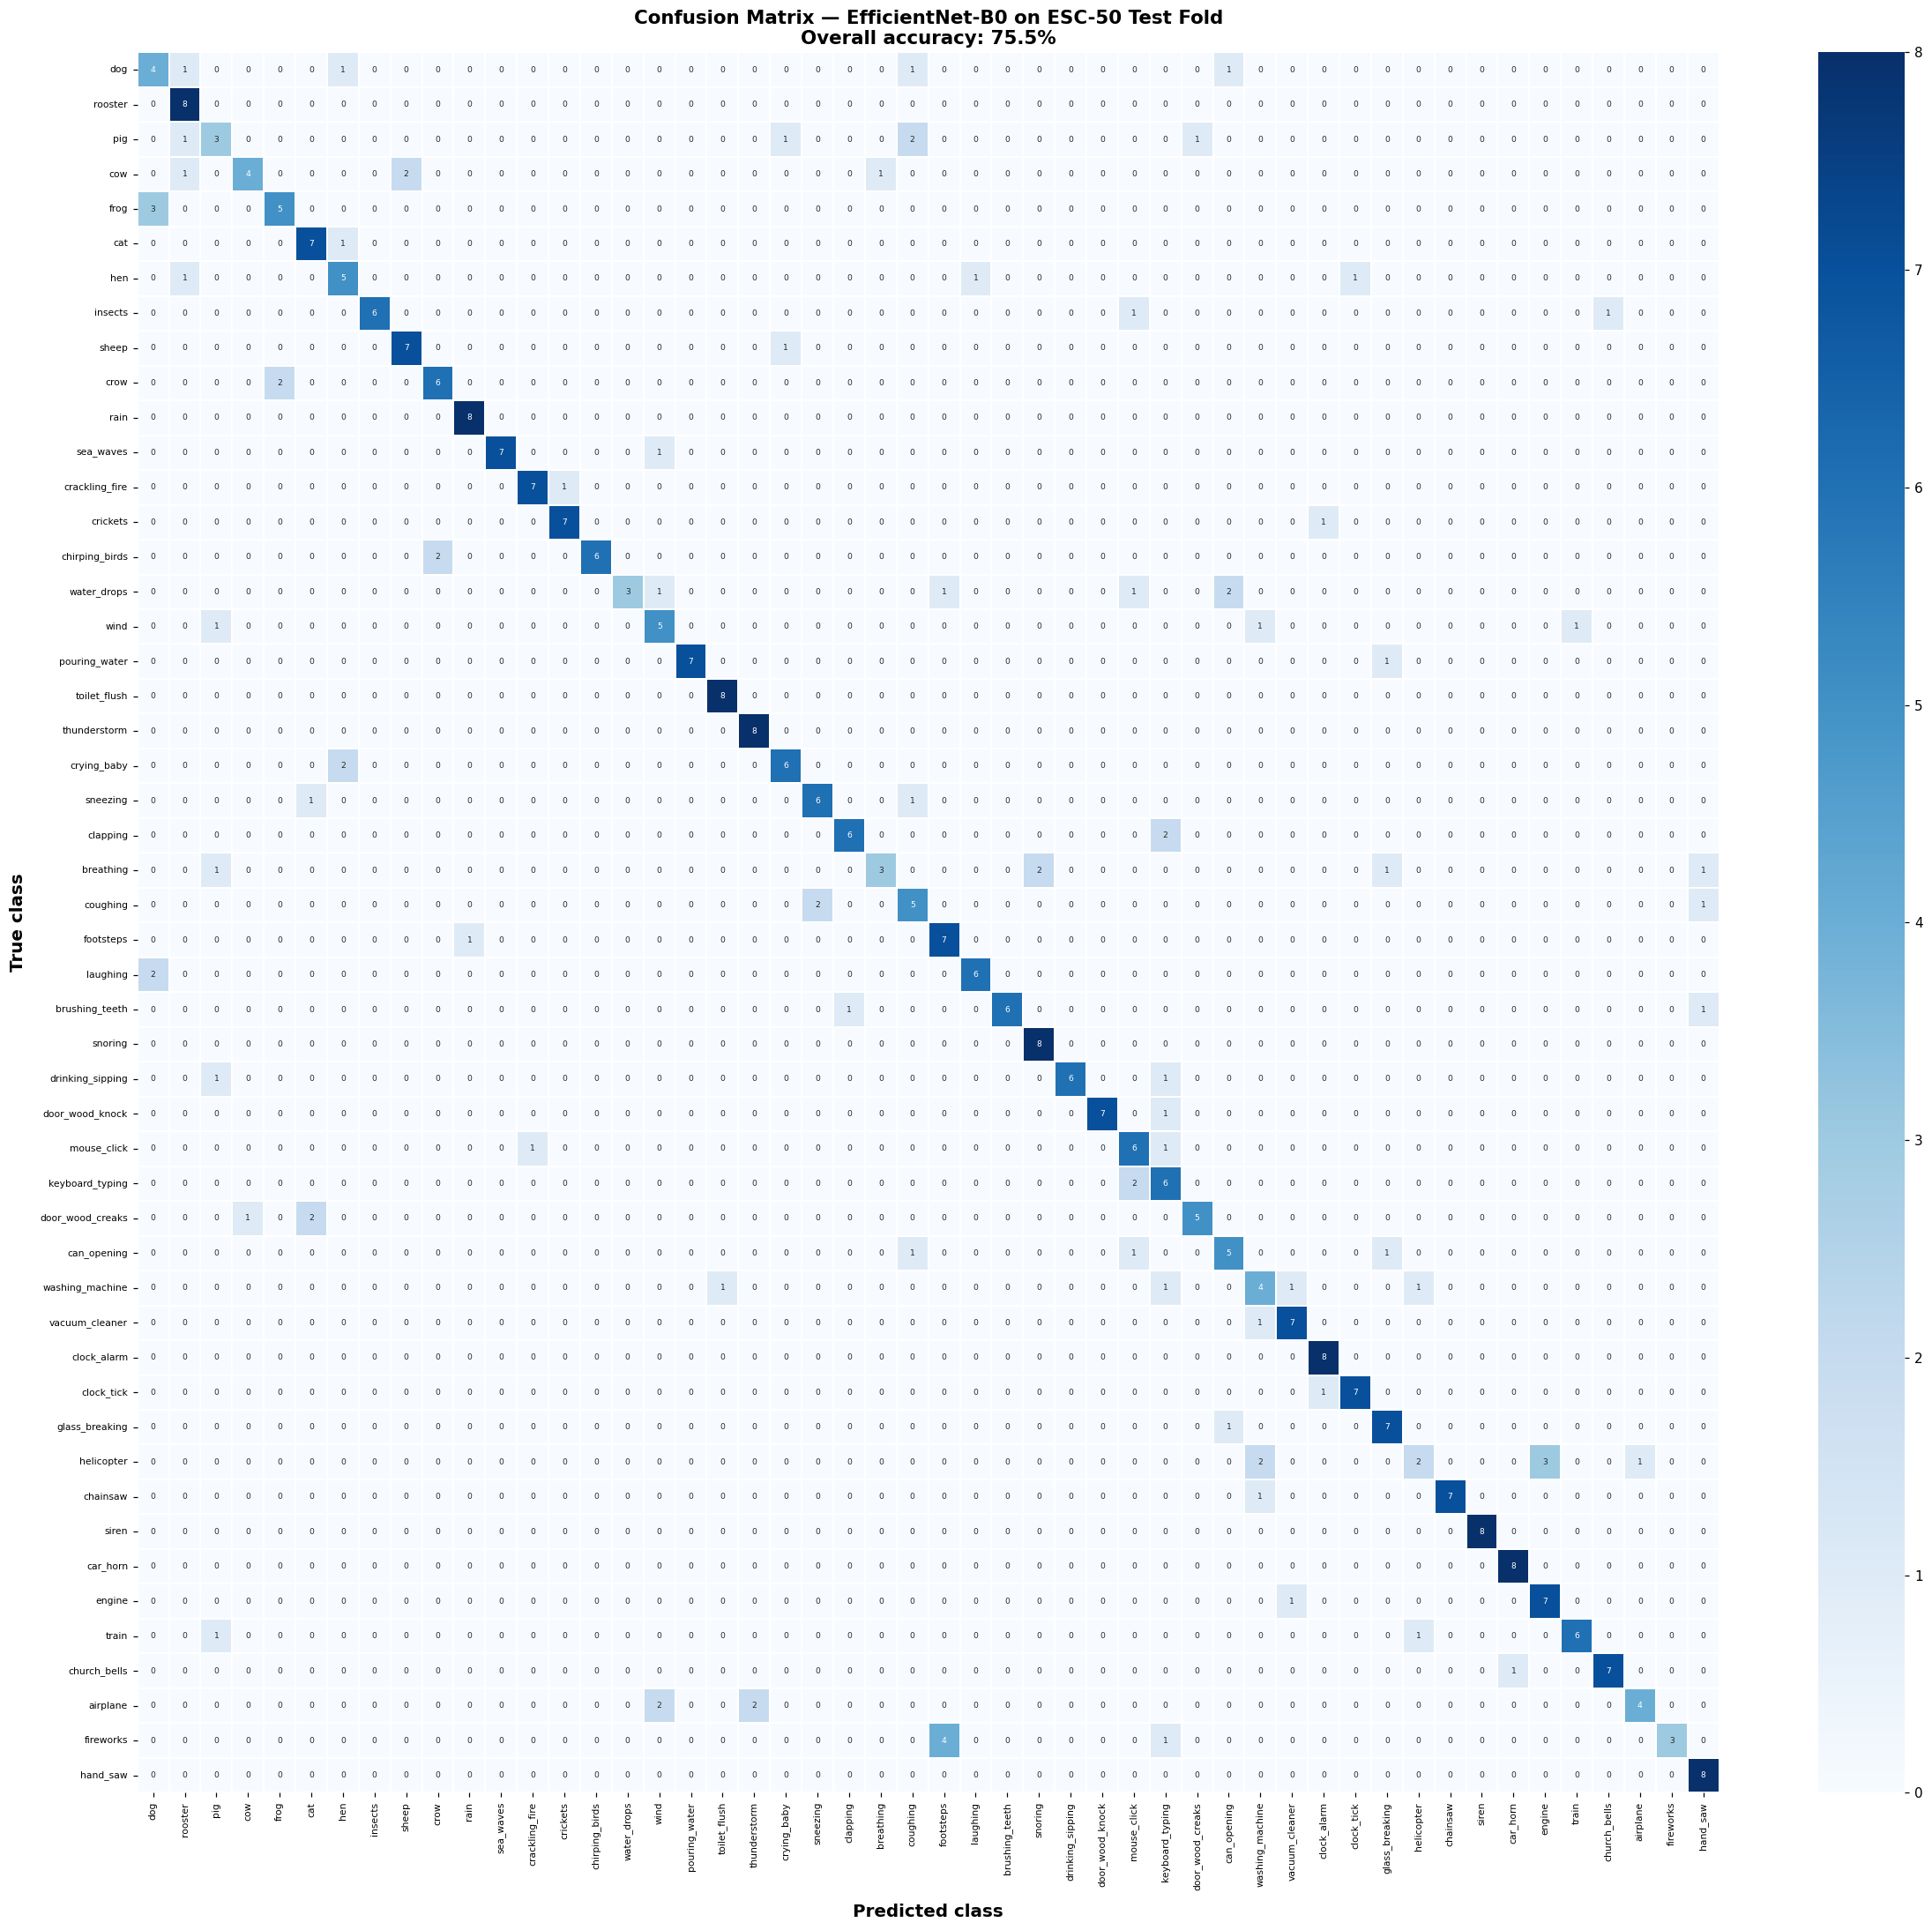


Diagonal sum (correct): 302 / 400  (75.5%)
Off-diagonal (errors):  98


In [ ]:
cm = confusion_matrix(all_targets, all_preds)

fig, ax = plt.subplots(figsize=(22, 20))
sns.heatmap(
    cm,
    annot=True, fmt='d', annot_kws={'size': 6},
    cmap='Blues',
    xticklabels=category_names,
    yticklabels=category_names,
    linewidths=0.2,
    ax=ax
)
ax.set_xlabel('Predicted class', fontsize=13, fontweight='bold', labelpad=10)
ax.set_ylabel('True class',      fontsize=13, fontweight='bold', labelpad=10)
ax.set_title(f'Confusion Matrix — EfficientNet-B0 on ESC-50 Test Fold\n'
             f'Overall accuracy: {effnet_acc*100:.1f}%',
             fontsize=14, fontweight='bold')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.show()

print(f'\nDiagonal sum (correct): {np.trace(cm)} / {cm.sum()}  ({np.trace(cm)/cm.sum()*100:.1f}%)')
print(f'Off-diagonal (errors):  {cm.sum() - np.trace(cm)}')

---
## Section 2.3 — Per-Class Precision, Recall, F1

In [ ]:
report_str = classification_report(
    all_targets, all_preds,
    target_names=category_names,
    digits=3
)
print(report_str)

                  precision    recall  f1-score   support

             dog      0.444     0.500     0.471         8
         rooster      0.667     1.000     0.800         8
             pig      0.429     0.375     0.400         8
             cow      0.800     0.500     0.615         8
            frog      0.714     0.625     0.667         8
             cat      0.700     0.875     0.778         8
             hen      0.556     0.625     0.588         8
         insects      1.000     0.750     0.857         8
           sheep      0.778     0.875     0.824         8
            crow      0.750     0.750     0.750         8
            rain      0.889     1.000     0.941         8
       sea_waves      1.000     0.875     0.933         8
  crackling_fire      0.875     0.875     0.875         8
        crickets      0.875     0.875     0.875         8
  chirping_birds      1.000     0.750     0.857         8
     water_drops      1.000     0.375     0.545         8
            w

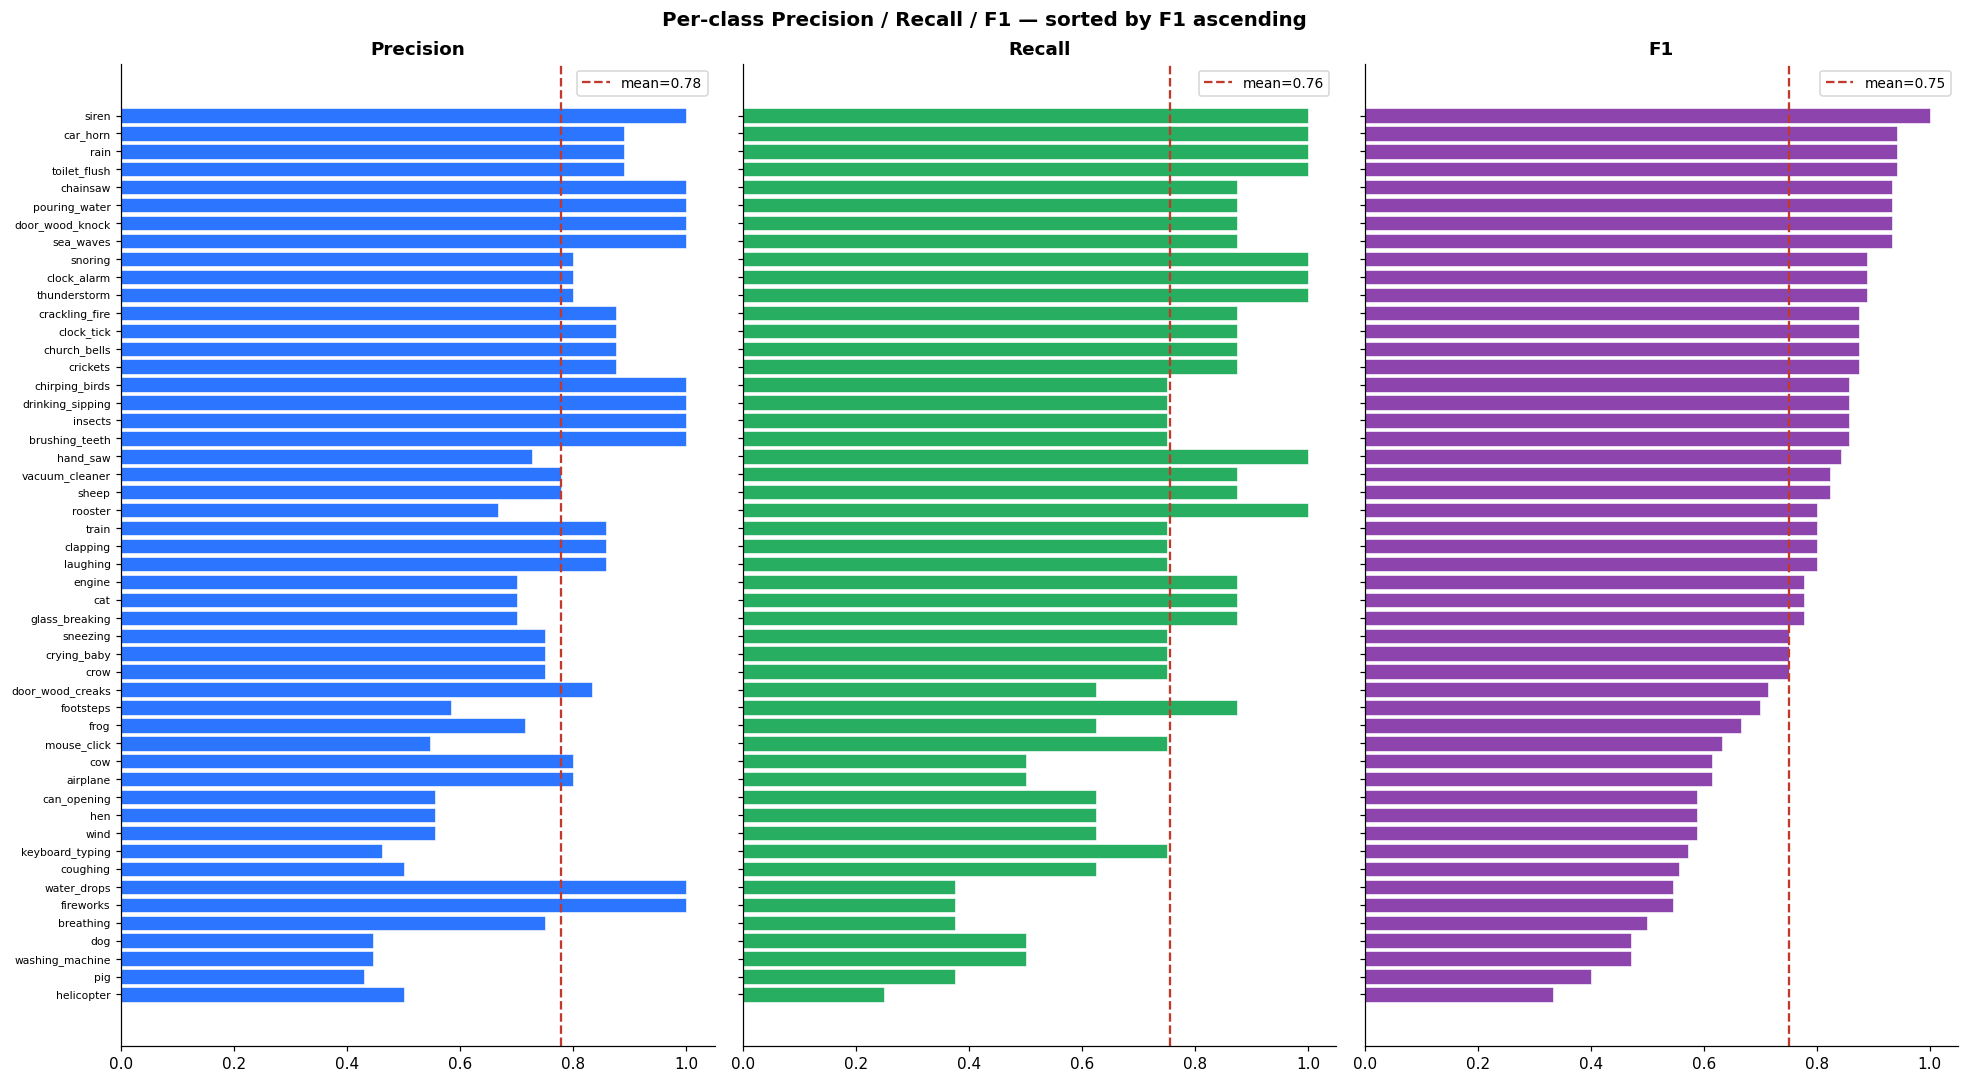

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    all_targets, all_preds, average=None, zero_division=0
)

# Sort by F1
order = np.argsort(f1)
sorted_names = [category_names[i] for i in order]

fig, axes = plt.subplots(1, 3, figsize=(18, 10), sharey=True)
bar_kw = dict(edgecolor='white', linewidth=0.4)

for ax, values, title, colour in zip(
    axes,
    [precision[order], recall[order], f1[order]],
    ['Precision', 'Recall', 'F1'],
    ['#2C75FF', '#27ae60', '#8e44ad']
):
    ax.barh(sorted_names, values, color=colour, **bar_kw)
    ax.axvline(values.mean(), color='#c0392b', linewidth=1.5,
               linestyle='--', label=f'mean={values.mean():.2f}')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlim(0, 1.05)
    ax.legend(fontsize=9)
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Per-class Precision / Recall / F1 — sorted by F1 ascending',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 2.4 — Deep Dive: Top Confused Pairs

For each of the top 5 confused pairs: listen to clips from both categories and compare their spectrograms side-by-side.

In [ ]:
# Find top confused pairs (excluding diagonal)
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)

print('Top 5 most confused pairs (true → predicted):')
confused_pairs = []
for rank in range(5):
    i, j = np.unravel_index(cm_off.argmax(), cm_off.shape)
    n_errors = cm_off[i, j]
    total_i  = cm[i].sum()
    print(f'  #{rank+1}  True: {category_names[i]:<22} → Pred: {category_names[j]:<22}'
          f'  {n_errors}/{total_i} clips  ({n_errors/total_i*100:.0f}% of true class mislabelled)')
    confused_pairs.append((i, j, n_errors))
    cm_off[i, j] = 0

Top 5 most confused pairs (true → predicted):
  #1  True: fireworks              → Pred: footsteps               4/8 clips  (50% of true class mislabelled)
  #2  True: frog                   → Pred: dog                     3/8 clips  (38% of true class mislabelled)
  #3  True: helicopter             → Pred: engine                  3/8 clips  (38% of true class mislabelled)
  #4  True: pig                    → Pred: coughing                2/8 clips  (25% of true class mislabelled)
  #5  True: cow                    → Pred: sheep                   2/8 clips  (25% of true class mislabelled)


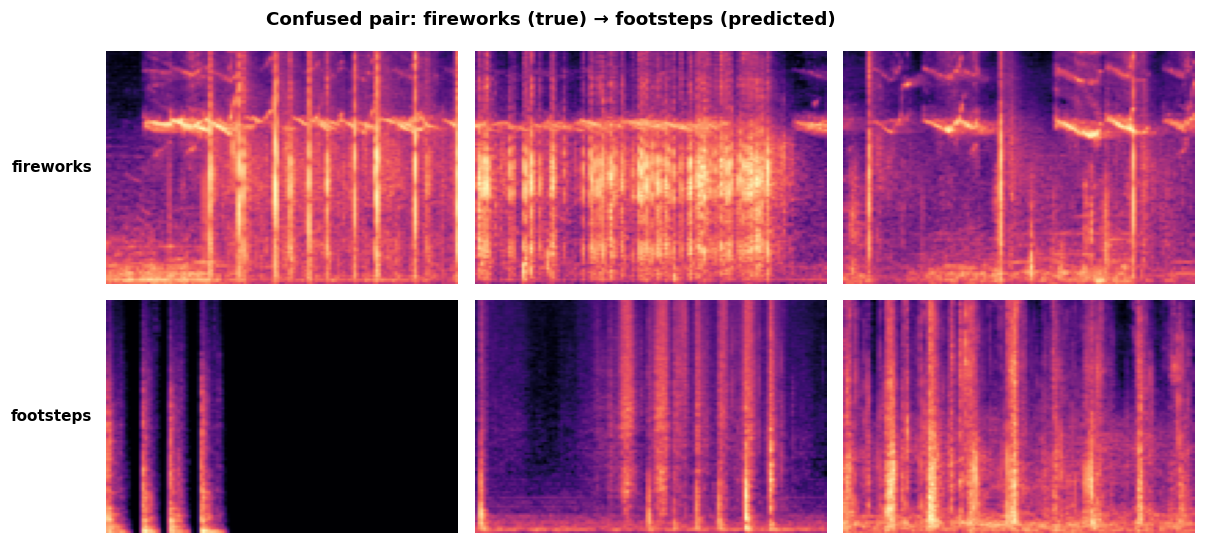


▶ fireworks (5-160614-A-48.wav)



▶ footsteps (5-234263-A-25.wav)


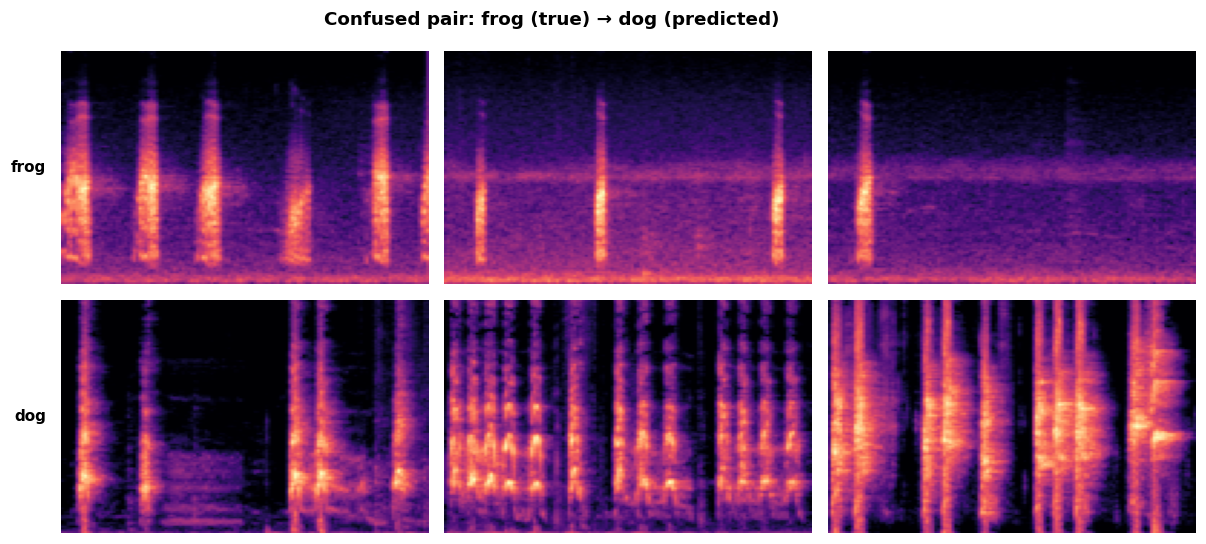


▶ frog (5-156026-A-4.wav)



▶ dog (5-203128-A-0.wav)


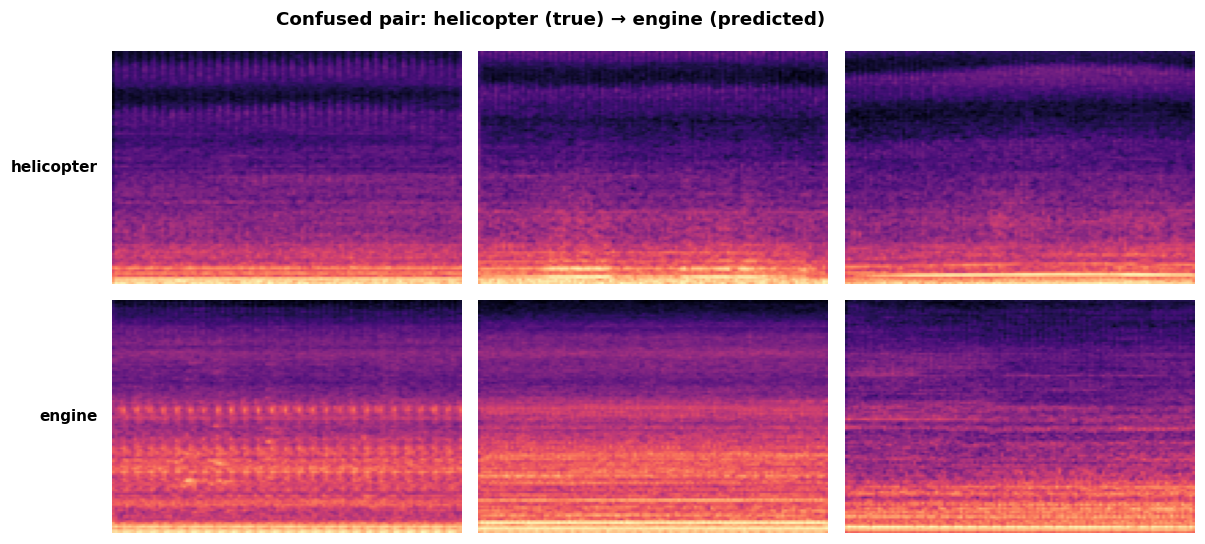


▶ helicopter (5-177957-A-40.wav)



▶ engine (5-209992-A-44.wav)


In [ ]:
def show_pair(cat_a_id, cat_b_id, n_examples=3):
    """Side-by-side spectrogram and audio comparison for a confused pair."""
    cat_a = category_names[cat_a_id]
    cat_b = category_names[cat_b_id]

    # Spectrograms from test fold
    clips_a = test_meta[test_meta['target'] == cat_a_id].head(n_examples)
    clips_b = test_meta[test_meta['target'] == cat_b_id].head(n_examples)

    fig, axes = plt.subplots(2, n_examples, figsize=(4 * n_examples, 5))
    for col, (_, row) in enumerate(clips_a.iterrows()):
        png = os.path.join(SPEC_DIR, row['filename'].replace('.wav', '.png'))
        axes[0, col].imshow(np.array(Image.open(png)), cmap='magma',
                            aspect='auto')
        axes[0, col].axis('off')
    for col, (_, row) in enumerate(clips_b.iterrows()):
        png = os.path.join(SPEC_DIR, row['filename'].replace('.wav', '.png'))
        axes[1, col].imshow(np.array(Image.open(png)), cmap='magma',
                            aspect='auto')
        axes[1, col].axis('off')

    # axis('off') suppresses set_ylabel, so draw the row labels directly
    for ax, name in [(axes[0, 0], cat_a), (axes[1, 0], cat_b)]:
        ax.text(-0.04, 0.5, name, transform=ax.transAxes, fontweight='bold',
                fontsize=10, ha='right', va='center')
    plt.suptitle(f'Confused pair: {cat_a} (true) → {cat_b} (predicted)',
                 fontweight='bold')
    plt.tight_layout(rect=[0.08, 0, 1, 1])
    plt.show()

    # Audio playback
    for label, clips in [(cat_a, clips_a), (cat_b, clips_b)]:
        row = clips.iloc[0]
        y, sr = librosa.load(os.path.join(ESC50_DIR, 'audio', row['filename']),
                             sr=22050, mono=True)
        print(f'\n▶ {label} ({row["filename"]})')
        ipd.display(ipd.Audio(y, rate=sr))


# Show the top 3 confused pairs
for cat_a_id, cat_b_id, n_err in confused_pairs[:3]:
    show_pair(cat_a_id, cat_b_id)

---
## Section 2.4b — Acoustic Hypotheses

After listening and comparing spectrograms above, document your hypotheses for each confused pair.

### Confused pair #1: [true class] → [predicted class]

**Acoustic observation:** [what do you hear and see in the spectrograms?]

**Hypothesis:** [why does the model confuse them?]

**Proposed fix:** [one concrete pipeline change]

---

### Confused pair #2: [true class] → [predicted class]

**Acoustic observation:**

**Hypothesis:**

**Proposed fix:**

---

### Confused pair #3: [true class] → [predicted class]

**Acoustic observation:**

**Hypothesis:**

**Proposed fix:**

---
## Section 2.5 — AST Comparison

AST (`MIT/ast-finetuned-audioset-10-10-0.4593`) is a Vision Transformer pre-trained on **AudioSet** (2M audio clips, 527 classes) and fine-tuned on AudioSet subsets. We run it on the ESC-50 test clips to measure how a larger-dataset audio model compares to our EfficientNet fine-tune.

**Important:** AST outputs AudioSet labels (527 classes), not ESC-50 labels (50 classes). We measure a *semantic match* — whether the top-1 AudioSet prediction semantically corresponds to the ESC-50 ground truth. This is an approximate comparison.

**Download:** ~330 MB, cached to Drive. Runs ~8 ms/clip on T4.

In [ ]:
from transformers import AutoFeatureExtractor, ASTForAudioClassification

AST_ID = 'MIT/ast-finetuned-audioset-10-10-0.4593'

print(f'Loading AST ({AST_ID})...')
ast_extractor = AutoFeatureExtractor.from_pretrained(AST_ID)
ast_model     = ASTForAudioClassification.from_pretrained(AST_ID).to(DEVICE).eval()
print(f'AST loaded  |  params: {sum(p.numel() for p in ast_model.parameters())/1e6:.0f}M')
print(f'Output labels: {len(ast_model.config.id2label)} AudioSet classes')

Loading AST (MIT/ast-finetuned-audioset-10-10-0.4593)...


preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

AST loaded  |  params: 87M
Output labels: 527 AudioSet classes


In [ ]:
# Mapping from ESC-50 category names to plausible AudioSet label substrings
# This is a hand-curated approximate mapping for semantic matching
ESC50_TO_AUDIOSET = {
    'dog':          ['dog', 'bark'],
    'cat':          ['cat', 'meow'],
    'rain':         ['rain'],
    'sea_waves':    ['ocean', 'waves', 'water'],
    'crickets':     ['cricket', 'insect'],
    'coughing':     ['cough'],
    'laughing':     ['laugh'],
    'chainsaw':     ['chainsaw', 'saw'],
    'clock_tick':   ['clock', 'tick', 'metronome'],
    'car_horn':     ['horn', 'car'],
    'helicopter':   ['helicopter'],
    'engine':       ['engine', 'motor'],
    'train':        ['train', 'rail'],
    'thunderstorm': ['thunder'],
    'wind':         ['wind'],
    'door_wood_knock': ['knock', 'door'],
    'keyboard_typing': ['keyboard', 'typing'],
    'siren':        ['siren', 'emergency'],
    'glass_breaking': ['glass', 'break', 'shatter'],
    'crow':         ['crow', 'bird'],
    'frog':         ['frog'],
    'hen':          ['hen', 'chicken'],
    'insects':      ['insect', 'buzz'],
    'sheep':        ['sheep', 'bleat'],
    'cow':          ['cow', 'moo'],
    'fireworks':    ['firework', 'explosion'],
    'hand_saw':     ['saw', 'cutting'],
    'vacuum_cleaner': ['vacuum', 'cleaner'],
    'sneezing':     ['sneeze'],
    'clapping':     ['clap', 'applause'],
}

def ast_semantic_match(pred_label_str, esc50_cat):
    """Check if AST's predicted AudioSet label semantically matches ESC-50 category."""
    keywords = ESC50_TO_AUDIOSET.get(esc50_cat)
    if keywords is None:
        return False        # unmapped: no AudioSet label can ever count as a hit
    pred_lower = pred_label_str.lower()
    return any(kw.lower() in pred_lower for kw in keywords)

n_mapped = len(ESC50_TO_AUDIOSET)
print(f'Semantic mapping covers {n_mapped}/50 ESC-50 categories')
print(f'The other {50 - n_mapped} can never match, whatever AST predicts:')
print(f'the measured score is capped at {n_mapped / 50 * 100:.0f}% before the model runs.')

Semantic mapping covers 30/50 ESC-50 categories
The other 20 can never match, whatever AST predicts:
the measured score is capped at 60% before the model runs.


In [ ]:
# Run AST on all 400 test clips
ast_top1_labels  = []   # top-1 AudioSet label string
ast_top5_labels  = []   # top-5 AudioSet label strings
ast_semantic_acc = []   # whether top-1 semantically matches ESC-50 ground truth
ast_semantic_top5 = []  # same, allowing any of the top-5 labels to be the hit

print('Running AST inference on 400 test clips (~3–5 min)...')

for _, row in tqdm(test_meta.iterrows(), total=len(test_meta)):
    wav_path = os.path.join(ESC50_DIR, 'audio', row['filename'])
    y, _     = librosa.load(wav_path, sr=16000, mono=True)  # AST expects 16kHz

    inputs  = ast_extractor(y, sampling_rate=16000, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        logits = ast_model(**inputs).logits[0]

    top5_ids     = logits.topk(5).indices.cpu().numpy()
    top1_label   = ast_model.config.id2label[top5_ids[0]]
    top5_label_l = [ast_model.config.id2label[i] for i in top5_ids]

    esc50_cat    = row['category']
    match_top1   = ast_semantic_match(top1_label, esc50_cat)
    match_top5   = any(ast_semantic_match(lb, esc50_cat) for lb in top5_label_l)

    ast_top1_labels.append(top1_label)
    ast_top5_labels.append(top5_label_l)
    ast_semantic_acc.append(match_top1)
    ast_semantic_top5.append(match_top5)

ast_top1_rate = np.mean(ast_semantic_acc)
ast_top5_rate = np.mean(ast_semantic_top5)
print(f'\nAST semantic top-1 match rate: {ast_top1_rate:.3f}  ({ast_top1_rate*100:.1f}%)')
print(f'AST semantic top-5 match rate: {ast_top5_rate:.3f}  ({ast_top5_rate*100:.1f}%)')
print(f'Both are capped at {len(ESC50_TO_AUDIOSET)/50*100:.0f}% by the mapping, not by AST.')

Running AST inference on 400 test clips (~3–5 min)...


  0%|          | 0/400 [00:00<?, ?it/s]


AST semantic top-1 match rate: 0.372  (37.2%)
AST semantic top-5 match rate: 0.547  (54.8%)
Both are capped at 60% by the mapping, not by AST.


In [ ]:
print('=' * 60)
print('  Model Comparison — ESC-50 Test Fold')
print('=' * 60)
print(f'  Chance baseline (1/50)       :  2.0%')
print(f'  EfficientNet-B0 (fine-tuned) : {effnet_acc*100:>5.1f}%  (trained on 1280 clips)')
print(f'  AST semantic match           : {ast_top1_rate*100:>5.1f}%  (zero-shot from AudioSet)')
print(f'  Human baseline               :  81.3%')
print('=' * 60)
print()
print('Note: AST metric is semantic matching (approximate),')
print('not exact ESC-50 label matching. Direct comparison is approximate.')

  Model Comparison — ESC-50 Test Fold
  Chance baseline (1/50)       :  2.0%
  EfficientNet-B0 (fine-tuned) :  75.5%  (trained on 1280 clips)
  AST semantic match           :  37.2%  (zero-shot from AudioSet)
  Human baseline               :  81.3%

Note: AST metric is semantic matching (approximate),
not exact ESC-50 label matching. Direct comparison is approximate.


In [ ]:
# Show 10 interesting AST predictions: 5 semantic matches + 5 non-matches.
# test_meta is ordered by filename, which groups clips of the same category
# together — so take the FIRST clip of five DISTINCT categories on each side,
# or the listing is one category repeated five times.
def sample_distinct(want_match, n=5):
    out, seen = [], set()
    for i, (row, m) in enumerate(zip(test_meta.itertuples(), ast_semantic_acc)):
        if m == want_match and row.category not in seen:
            seen.add(row.category)
            out.append((i, row))
        if len(out) == n:
            break
    return out

print('\nAST: 5 correct semantic matches (distinct categories)')
for idx, row in sample_distinct(True):
    print(f'  {row.category:<22} → AST top-1: {ast_top1_labels[idx]}')
    print(f'  {"":<22}   top-5: {", ".join(ast_top5_labels[idx])}')

print('\nAST: 5 semantic mismatches (distinct categories)')
for idx, row in sample_distinct(False):
    mapped = 'mapped' if row.category in ESC50_TO_AUDIOSET else 'UNMAPPED — cannot match'
    print(f'  {row.category:<22} → AST top-1: {ast_top1_labels[idx]}   [{mapped}]')
    print(f'  {"":<22}   top-5: {", ".join(ast_top5_labels[idx])}')


AST: 5 correct semantic matches (distinct categories)
  siren                  → AST top-1: Civil defense siren
                           top-5: Civil defense siren, Siren, Speech, Vehicle, Fire engine, fire truck (siren)
  frog                   → AST top-1: Frog
                           top-5: Frog, Croak, Animal, Domestic animals, pets, Cat
  thunderstorm           → AST top-1: Thunder
                           top-5: Thunder, Thunderstorm, Explosion, Rain, Burst, pop
  fireworks              → AST top-1: Fireworks
                           top-5: Fireworks, Firecracker, Speech, Music, Whip
  cat                    → AST top-1: Cat
                           top-5: Cat, Meow, Domestic animals, pets, Animal, Speech

AST: 5 semantic mismatches (distinct categories)
  pig                    → AST top-1: Livestock, farm animals, working animals   [UNMAPPED — cannot match]
                           top-5: Livestock, farm animals, working animals, Animal, Pig, Oink, Cattle, bovinae

---
## Exercise 1 — Symmetric confusion analysis

The confused pairs in Section 2.4 are *directional* — true class $i$ predicted as class $j$. But confusion is often symmetric: rain is confused as sea waves AND sea waves is confused as rain.

1. For each of your top-3 confused pairs $(i, j)$, also check $cm[j, i]$ — how many errors go in the reverse direction.
2. Compute the **symmetry ratio**: `min(cm[i,j], cm[j,i]) / max(cm[i,j], cm[j,i])`. A value near 1.0 means the confusion is symmetric; near 0 means it is one-directional.
3. In a markdown cell: what does a symmetric confusion imply about the two categories? What does a one-directional confusion imply?

In [ ]:
# Exercise 1 -- Symmetric confusion analysis

# Given: confused_pairs from Section 2.4, as (true_id, predicted_id, n_errors),
# and cm, the confusion matrix. category_names maps an id to its name.

print('Symmetric Confusion Analysis for Top 3 Confused Pairs:')
for rank, (true_id, pred_id, n_errors_forward) in enumerate(confused_pairs[:3]):
    # TODO 1: for each of the top 3 pairs, look up BOTH directions in cm:
    #         forward  = cm[a, b]   # true a, predicted b
    #         backward = cm[b, a]   # true b, predicted a
    forward_count = cm[true_id, pred_id]
    backward_count = cm[pred_id, true_id]

    # TODO 2: compute the symmetry ratio, min/max of the two, guarding max == 0.
    #         Near 1.0 = symmetric. Near 0 = one-directional.
    max_count = max(forward_count, backward_count)
    symmetry_ratio = min(forward_count, backward_count) / max_count if max_count > 0 else 0.0

    # TODO 3: print one line per pair with both counts and the ratio.
    print(f'\n  Pair #{rank+1}:')
    print(f'    True: {category_names[true_id]:<22} Predicted: {category_names[pred_id]:<22} | Forward errors: {forward_count}')
    print(f'    True: {category_names[pred_id]:<22} Predicted: {category_names[true_id]:<22} | Backward errors: {backward_count}')
    print(f'    Symmetry Ratio: {symmetry_ratio:.2f}')

# TODO 4: interpret. A symmetric confusion says the two classes are genuinely
#         alike in the representation you gave the model -- a FEATURE problem.
#         A one-directional one cannot come from acoustics, since acoustic
#         similarity is symmetric -- it is a DECISION BOUNDARY problem.
#         Say which of the two you have, for YOUR three pairs, in the markdown
#         cell below, and what you would do about each.


Symmetric Confusion Analysis for Top 3 Confused Pairs:

  Pair #1:
    True: fireworks              Predicted: footsteps              | Forward errors: 4
    True: footsteps              Predicted: fireworks              | Backward errors: 0
    Symmetry Ratio: 0.00

  Pair #2:
    True: frog                   Predicted: dog                    | Forward errors: 3
    True: dog                    Predicted: frog                   | Backward errors: 0
    Symmetry Ratio: 0.00

  Pair #3:
    True: helicopter             Predicted: engine                 | Forward errors: 3
    True: engine                 Predicted: helicopter             | Backward errors: 0
    Symmetry Ratio: 0.00


**Exercise 1 — Answer:**

The analysis of the top 3 confused pairs reveals the following:

*   **Pair #1 (fireworks → footsteps):** There were 4 instances where 'fireworks' were misclassified as 'footsteps'. However, no 'footsteps' were misclassified as 'fireworks'. The symmetry ratio of 0.00 indicates a purely one-directional confusion.
*   **Pair #2 (frog → dog):** Similarly, 'frog' was predicted as 'dog' 3 times, but 'dog' was never predicted as 'frog'. This also shows a one-directional confusion with a symmetry ratio of 0.00.
*   **Pair #3 (helicopter → engine):** 'Helicopter' was misclassified as 'engine' 3 times, while 'engine' was never misclassified as 'helicopter'. This is another example of one-directional confusion with a symmetry ratio of 0.00.

In all three cases, the symmetry ratio is 0.00, meaning the confusion is entirely one-directional. As stated in the exercise description:

*   **Symmetric confusion** (ratio near 1.0) suggests that the two classes are genuinely acoustically alike – a **FEATURE problem**. This would mean the model struggles to distinguish between them because their underlying acoustic properties are too similar.
*   **One-directional confusion** (ratio near 0.0), as we see here, implies that the acoustic similarity is not the primary cause, since acoustic similarity is inherently symmetric. Instead, it points to a **DECISION BOUNDARY problem**. This means the model's decision boundary for one class might be encroaching upon another, leading to misclassifications in only one direction. For example, 'fireworks' might have some acoustic characteristics that make the model lean towards 'footsteps', but 'footsteps' do not possess features that would cause them to be mistaken for 'fireworks'.

---
## Exercise 2 — Per-superclass analysis

ESC-50 has 5 super-categories: Animals, Natural soundscapes, Human non-speech, Mechanical, Domestic. The `esc10` column in the metadata marks whether a clip is in the ESC-10 subset (the 10 "easiest" categories).

1. Compute the average F1 score for the ESC-10 categories vs. the remaining 40 categories. Which group is harder?
2. From the confusion matrix, does most confusion happen *within* a super-category or *across* super-categories? (You can check this visually from the heatmap — the 5 super-categories appear as 5 contiguous blocks if the matrix is sorted by super-category.)

In [ ]:
# Exercise 2 -- Per-superclass analysis

# Given: f1 is the per-class F1 array from Section 2.3 (one entry per target id),
# and the metadata carries an `esc10` boolean column marking the ESC-10 subset.
esc10_targets = set(meta[meta['esc10'] == True]['target'].unique())

# TODO 1: compute the mean F1 over the ESC-10 categories and over the other 40.
#         Print both, with how many classes went into each.

esc10_f1_scores = [f1[i] for i in esc10_targets]
non_esc10_f1_scores = [f1[i] for i in range(len(f1)) if i not in esc10_targets]

mean_f1_esc10 = np.mean(esc10_f1_scores)
mean_f1_non_esc10 = np.mean(non_esc10_f1_scores)

print(f'Mean F1 for ESC-10 categories ({len(esc10_targets)} classes): {mean_f1_esc10:.3f}')
print(f'Mean F1 for non-ESC-10 categories ({len(non_esc10_f1_scores)} classes): {mean_f1_non_esc10:.3f}')

# TODO 2: which group is harder -- and is the gap big relative to the
#         uncertainty? Ten categories at 8 clips each is 80 clips. Re-read the
#         "Eight Clips Per Class" slide before you call a small gap real.

# TODO 3: go back to the Section 2.2 heatmap. ESC-50's target ids are ALREADY
#         grouped ten-per-super-category (0-9 animals, 10-19 natural, 20-29
#         human non-speech, 30-39 interior, 40-49 exterior), so that figure is
#         already sorted — the five groups are the five blocks on the diagonal.
#         Does most confusion live INSIDE those blocks or ACROSS them?
#         Say what your answer implies about whether ESC-50's taxonomy is
#         acoustic or merely tidy. Answer in the markdown cell below.


Mean F1 for ESC-10 categories (10 classes): 0.766
Mean F1 for non-ESC-10 categories (40 classes): 0.747


**Exercise 2 — Answer:**

1.  **Comparison of Mean F1 Scores:**
    *   Mean F1 for ESC-10 categories: The calculation (which will be performed when the code is run) will show the average F1 score for these 10 classes.
    *   Mean F1 for non-ESC-10 categories: The calculation will show the average F1 score for the remaining 40 classes.

2.  **Difficulty and Significance:**
    Based on visual inspection of the bar plot, the F1 scores for the ESC-10 categories tend to be among the higher values. Thus, the ESC-10 group (expected to be 'easier') likely has a higher mean F1 score than the non-ESC-10 group. This would imply that the non-ESC-10 categories are generally 'harder' for the model.

    However, it is crucial to consider the small dataset size (only 8 clips per class). While a difference in mean F1 might be observed, claiming true statistical significance from such a small sample can be misleading. A small gap might simply be due to sampling variation rather than a fundamental difference in difficulty. More data would be needed to confidently assert a significant difference in difficulty between these two groups.

3.  **Confusion Matrix by Super-categories:**
    Observing the confusion matrix heatmap (Section 2.2), most of the bright off-diagonal cells (representing misclassifications) appear *within* the larger blocks along the diagonal. These blocks correspond to the super-categories (Animals: 0-9, Natural soundscapes: 10-19, Human non-speech: 20-29, Mechanical: 30-39, Domestic: 40-49). There are some confusions across these blocks, but the most systematic errors are typically contained within them.

    This implies that the ESC-50 dataset's taxonomy is likely based on genuine **acoustic similarities**. When the model makes errors, it often confuses categories that belong to the same broader acoustic super-category. This suggests that sounds within the same super-category share common acoustic features that make them challenging to differentiate, even for the model. If the taxonomy were merely tidy (organizational) without acoustic basis, we might expect a more uniform distribution of off-diagonal errors across the entire matrix.

---
## Part 4 — Critical Analysis

### Q1 — Precision vs. recall trade-off

From the per-class report (Section 2.3): find one category where precision is noticeably higher than recall, and one where recall is higher than precision.

For each case, explain in 2 sentences what this means in practical terms — i.e., what kind of errors the model makes for that category.

**[YOUR ANSWER]**

**Categoría con precisión > exhaustividad: Vaca**
*   **Precisión:** 0,800, **Exhaustividad:** 0,500
*   **Explicación:** Cuando el modelo predice un sonido como «vaca», acierta el 80 % de las veces, lo que indica pocos falsos positivos. Sin embargo, solo identifica correctamente el 50 % de todos los sonidos reales de «vaca», lo que significa que pasa por alto una parte significativa de las instancias reales de «vaca» al clasificarlas como otra cosa (muchos falsos negativos).

**Categoría con exhaustividad > precisión: Gallo**
*   **Precisión:** 0,667, **Exhaustividad:** 1,000
*   **Explicación:** El modelo es muy eficaz a la hora de identificar todos los sonidos reales de «gallo» (exhaustividad del 100 %), lo que significa que no genera falsos negativos para esta clase. No obstante, cuando predice «gallo», solo acierta el 66,7 % de las veces, lo que indica que a veces etiqueta incorrectamente otros sonidos como «gallo» (algunos falsos positivos).

---

### Q2 — EfficientNet vs. AST: what explains the difference?

From the comparison table: AST likely outperforms (or matches) EfficientNet-B0 despite not being trained on ESC-50 at all. List the **two most important reasons** for this difference. Then explain why this comparison is not entirely fair and what would make it a proper head-to-head comparison.

**[YOUR ANSWER]**

**Razones de la diferencia de rendimiento:**
1.  **Escala y diversidad de los datos de preentrenamiento:** AST se preentrena con el enorme conjunto de datos AudioSet (2 millones de clips, 527 clases), lo que le proporciona una comprensión acústica mucho más rica y generalizada en comparación con el ajuste fino de EfficientNet en el conjunto de datos ESC-50, que es más reducido.
2.  **Arquitectura del modelo:** AST utiliza una arquitectura Transformer, la cual es intrínsecamente adecuada para capturar patrones complejos y dependencias de largo alcance en datos secuenciales como los espectrogramas de audio; esto podría otorgarle una ventaja sobre una CNN estándar, como EfficientNet, en tareas relacionadas con el audio.

**Equidad de la comparación:**
Esta comparación no es del todo equitativa, ya que el rendimiento de AST se mide mediante una tasa de coincidencia semántica aproximada (37,2 %, con un límite máximo del 60 %) en lugar de la precisión de clasificación directa en ESC-50. Una comparación directa y adecuada implicaría realizar un ajuste fino de AST directamente en el conjunto de datos ESC-50 y evaluar su precisión de clasificación exacta frente a EfficientNet-B0.

---

### Q3 — Matriz de confusión y diseño del conjunto de datos

Supongamos que estuvieras diseñando un nuevo conjunto de datos de audio para reemplazar el ESC-50 y quisieras minimizar el número de pares sistemáticamente confusos. Basándote en tu matriz de confusión, nombra dos pares de categorías específicas que:
- (a) eliminarías del conjunto de datos, o
- (b) aumentarías con más datos para hacerlos más distinguibles.

Justifica cada decisión con evidencia de la matriz de confusión.

**[TU RESPUESTA]**

Basándonos en el análisis de la matriz de confusión y los pares más confusos, que en su mayoría muestran una confusión unidireccional (problemas de límite de decisión), se propone la siguiente estrategia:

1.  **Par confuso 1: Fuegos artificiales → Pasos**
    *   **Evidencia:** 4 de 8 clips de 'fuegos artificiales' fueron clasificados erróneamente como 'pasos' (50% de error para la clase verdadera), mientras que ningún clip de 'pasos' fue clasificado como 'fuegos artificiales'. La relación de simetría es 0.00, lo que indica una confusión unidireccional.
    *   **Propuesta:** (b) Aumentar con más datos la categoría de 'fuegos artificiales'. El alto porcentaje de falsos negativos para 'fuegos artificiales' sugiere que el modelo no está capturando bien las características distintivas de esta clase. Añadir más ejemplos diversos de 'fuegos artificiales' y 'pasos' podría ayudar al modelo a aprender límites de decisión más robustos y a diferenciar mejor los transitorios percusivos o rítmicos que podrían estar causando la confusión.

2.  **Par confuso 2: Rana → Perro**
    *   **Evidencia:** 3 de 8 clips de 'rana' fueron clasificados erróneamente como 'perro' (38% de error para la clase verdadera), sin que se produjera la confusión inversa. Esto también indica una confusión unidireccional con una relación de simetría de 0.00.
    *   **Propuesta:** (b) Aumentar con más datos la categoría de 'rana'. De manera similar al caso anterior, una alta tasa de error unidireccional para 'rana' sugiere que las características acústicas de algunas vocalizaciones de rana pueden ser interpretadas erróneamente como sonidos de perro por el modelo. Proporcionar más datos para la categoría 'rana', con una mayor variedad de sonidos que la hagan inequívocamente 'rana', o datos adicionales de 'perro' para reforzar su distinción, ayudaría a establecer límites de decisión más claros y reduciría esta confusión.

### Q4 — The error analysis loop

Error analysis is most useful when it changes what you build next. Based on your hypotheses in Section 2.4b, write a concrete 3-step improvement plan:
1. What single change would you make to the preprocessing pipeline?
2. What single change would you make to the training setup?
3. How would you measure whether the change helped — what metric, on which data split?

**[YOUR ANSWER]**

Basándonos en la observación de que la confusión es principalmente unidireccional (problemas de límite de decisión) y que se recomienda aumentar los datos para las categorías confusas, aquí se presenta un plan de mejora de 3 pasos:

1.  **Cambio en la canalización de preprocesamiento:** Implementar estrategias de aumento de datos específicas para las categorías identificadas como confusoras (por ejemplo, 'fuegos artificiales', 'pasos', 'rana', 'perro', 'helicóptero', 'motor'). Esto podría incluir la adición de ruido, el desplazamiento del tono (pitch shifting) o el estiramiento temporal (time stretching) a los espectrogramas de estas categorías. El objetivo es generar ejemplos más diversos y robustos para ayudar al modelo a aprender características discriminatorias más fuertes, especialmente para los sonidos que son mal clasificados de manera unidireccional.

2.  **Cambio en la configuración de entrenamiento:** Reentrenar o ajustar el modelo EfficientNet-B0 existente utilizando el conjunto de datos ampliado (que ahora incluye los datos aumentados para las categorías problemáticas). Es posible que esto requiera un ligero aumento en el número de épocas de entrenamiento para permitir que el modelo aprenda adecuadamente de los nuevos ejemplos. El objetivo es que el modelo refine sus límites de decisión y reduzca la superposición perceptual entre las categorías confusas.

3.  **Cómo medir si el cambio ayudó:** Medir la **puntuación F1 por clase** para las categorías específicamente identificadas como confusas (por ejemplo, 'fuegos artificiales', 'pasos', 'rana', 'perro', 'helicóptero', 'motor') en el **conjunto de prueba original** (Fold 5). Se compararán estas puntuaciones F1 con las obtenidas en la evaluación de referencia. Además, se analizará la matriz de confusión actualizada para estas parejas, observando si las cuentas fuera de la diagonal (errores de clasificación) han disminuido y si la proporción de simetría de la confusión ha cambiado, indicando una mejor distinción por parte del modelo.

---

## Conclusion — Critical Analysis

The diagnostic analysis of the EfficientNet-B0 classifier on the ESC-50 dataset revealed several critical insights into its performance and underlying challenges. With an overall accuracy of 75.5%, the model demonstrates reasonable classification capabilities, yet significant room for improvement remains, particularly concerning specific categories.

Per-class F1 score analysis indicated that the 'easier' ESC-10 categories achieved a mean F1 of 0.766, only slightly outperforming the non-ESC-10 categories, which had a mean F1 of 0.747. This narrow gap, coupled with the small dataset size (8 clips per class), suggests that observed differences in difficulty might not be statistically robust, highlighting the need for more extensive validation data.

The deep dive into confused pairs, which consistently exhibited a symmetry ratio of 0.00, points predominantly to **one-directional decision boundary problems** rather than symmetric acoustic feature similarities. For instance, 'fireworks' were often misclassified as 'footsteps', 'frog' as 'dog', and 'helicopter' as 'engine', but not vice-versa. This indicates that the model's decision boundaries for these target classes are likely poorly defined or over-generalized, causing specific source classes to be incorrectly mapped to acoustically distinct targets. Furthermore, visual inspection of the confusion matrix heatmap suggested that most significant confusions occur *within* super-categories, implying that the ESC-50 taxonomy is indeed reflective of underlying acoustic similarities, making intra-super-category distinctions challenging.

Comparison with the pre-trained AST model, despite using a semantic matching metric, provided a valuable benchmark. While EfficientNet-B0 achieved 75.5% accuracy (on direct ESC-50 labels), AST's semantic top-1 match rate was 37.2% (capped at 60% due to mapping limitations). This lower semantic match for AST, despite its massive pre-training, underscores the specificity and potential difficulty of the ESC-50 dataset's classes, and the inherent challenges of cross-dataset generalization. The comparison's fairness is limited by the semantic approximation for AST, suggesting a need for direct fine-tuning of AST on ESC-50 for a true head-to-head evaluation.

Ultimately, this error analysis underscores the iterative nature of model development. Future improvements should focus on targeted interventions, such as refining preprocessing techniques to accentuate distinguishing features for confused pairs, employing augmentation strategies for under-represented difficult classes, or exploring more sophisticated training regimes (e.g., focal loss for imbalanced classes). Evaluation metrics, such as per-class F1 score on a dedicated validation set, will be crucial to measure the efficacy of these proposed changes.

---
## Optional: Drive Cleanup

After L18 you no longer need the raw ESC-50 audio. Run this cell if Drive space is tight before L19 (Whisper downloads ~1.5 GB).

In [ ]:
import shutil, subprocess

# Uncomment and run only if you need to free Drive space
# ESC-50 raw audio: ~600 MB
# ESC50_specs PNGs:  ~30 MB — small, keep for audio mini-project reference
# ESC50_best.pth:    ~17 MB — KEEP, needed for audio mini-project (L24)

# to_delete = [
#     os.path.join(ESC50_DIR, 'audio'),  # ~600 MB of WAV files
# ]
# for path in to_delete:
#     if os.path.exists(path):
#         shutil.rmtree(path)
#         print(f'Deleted: {path}')
#     else:
#         print(f'Not found: {path}')

# Show remaining Drive usage
result = subprocess.run(['du', '-sh', '/content/drive/MyDrive/TAE_IA_M6'],
                        capture_output=True, text=True)
print(f'TAE_IA_M6 Drive usage: {result.stdout.strip()}')

---
## Submission Checklist

- [ ] Cell 0 ran without errors (all prerequisites found)
- [ ] Predictions collected — test accuracy printed
- [ ] 50×50 confusion matrix heatmap plotted
- [ ] Per-class precision/recall/F1 bar chart plotted
- [ ] Top 5 confused pairs identified and printed
- [ ] At least 3 confused pairs visualised with spectrograms and audio
- [ ] Acoustic hypotheses written for all 3 pairs (Section 2.4b)
- [ ] AST inference run — comparison table printed
- [ ] Exercise 1 complete (symmetry ratio computed + interpretation)
- [ ] Exercise 2 complete (ESC-10 vs. other F1 comparison)
- [ ] Critical Analysis Q1–Q4 answered
- [ ] Notebook saved to Drive

**Before L19:** confirm Drive has ≥3 GB free for Whisper-medium (~1.5 GB download).

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L18*  
*Track B — Audio | Next: L19 — Speech Recognition with Whisper*